Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 784)
Testing Shape : (10000, 784)


In [ ]:
def build_model(learning_rate):

    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
learning_rates = [0.1, 0.01, 0.001]

lr_results = []

for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    model = build_model(lr)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    lr_results.append([lr, loss, accuracy])

lr_df = pd.DataFrame(
    lr_results,
    columns=["Learning Rate", "Loss", "Accuracy"]
)

print(lr_df)


Training with Learning Rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Learning Rate = 0.01

Training with Learning Rate = 0.001
   Learning Rate      Loss  Accuracy
0          0.100  0.803789    0.7614
1          0.010  0.132319    0.9671
2          0.001  0.067331    0.9799


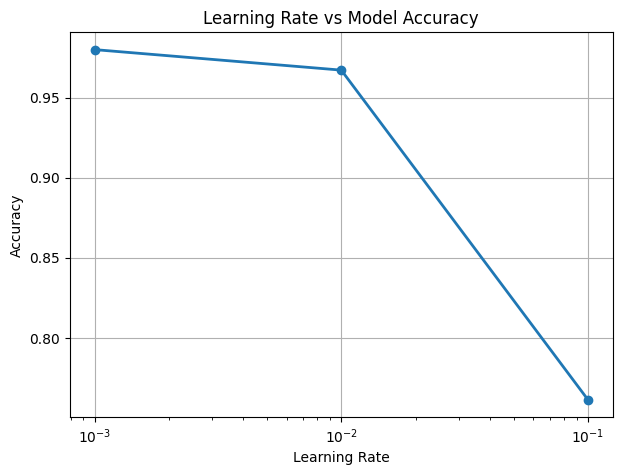

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    lr_df["Learning Rate"],
    lr_df["Accuracy"],
    marker='o',
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Model Accuracy")
plt.grid(True)

plt.show()

In [ ]:
epochs_list = [5, 10, 20]

epoch_results = []

for ep in epochs_list:

    print(f"\nTraining for {ep} Epochs")

    model = build_model(0.001)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    epoch_results.append([ep, loss, accuracy])

epoch_df = pd.DataFrame(
    epoch_results,
    columns=["Epochs", "Loss", "Accuracy"]
)

print(epoch_df)


Training for 5 Epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training for 10 Epochs

Training for 20 Epochs
   Epochs      Loss  Accuracy
0       5  0.082338    0.9744
1      10  0.084201    0.9798
2      20  0.113344    0.9766


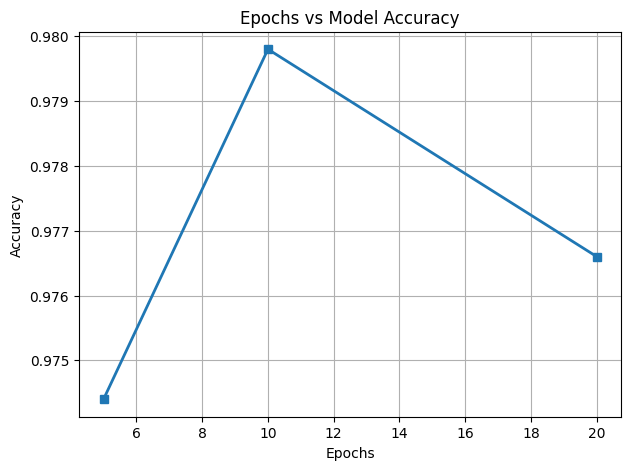

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    epoch_df["Epochs"],
    epoch_df["Accuracy"],
    marker='s',
    linewidth=2
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Epochs vs Model Accuracy")
plt.grid(True)

plt.show()

In [ ]:
best_model = build_model(0.001)

history = best_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

test_loss, test_accuracy = best_model.evaluate(
    x_test,
    y_test
)

print("\nFinal Test Accuracy:", round(test_accuracy * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9149 - loss: 0.3069 - val_accuracy: 0.9469 - val_loss: 0.1751
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9655 - loss: 0.1149 - val_accuracy: 0.9678 - val_loss: 0.1074
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9774 - loss: 0.0746 - val_accuracy: 0.9724 - val_loss: 0.0923
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9840 - loss: 0.0526 - val_accuracy: 0.9735 - val_loss: 0.0853
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9741 - val_loss: 0.0881
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9910 - loss: 0.0289 - val_accuracy: 0.9764 - val_loss: 0.0887
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9929 - loss: 0.0229 - val_accuracy: 0.9767 - val_loss: 0.0842
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 

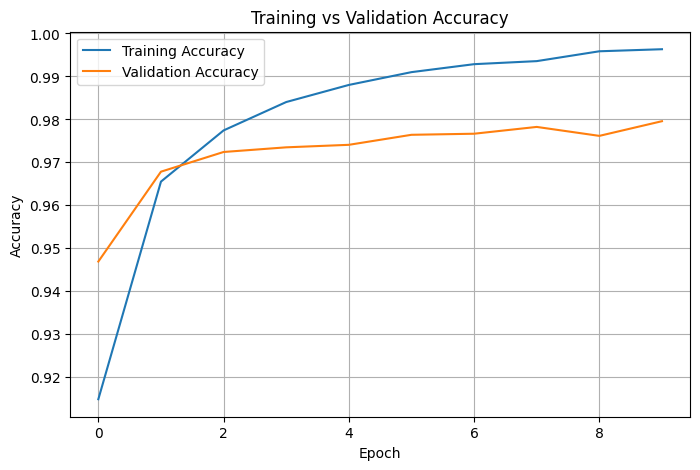

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()